# Laboratorio: Algoritmos Genéticos - Curso 2
### Universidad de Cundinamarca - Seccional Ubaté
**Integrantes:** (Edwar Arley Fontecha Chiquiza y Daniel Esteban Chavez Marroquin)

## Ejercicios 1 y 2 - Portafolio de Inversiones y Selección de Personal

In [11]:
import random

class AlgoritmoGenetico:
    """
    Clase genérica y reutilizable para implementar un Algoritmo Genético (AG)
    con genotipo binario, que puede resolver distintos problemas de optimización
    combinatoria (Mochila, Portafolio, Selección de Personal, etc.).
    """

    def __init__(self, population_size, chromosome_length, pc, pm,
                 fitness_func, decode_func, selection_method='tournament',
                 tournament_size=3, elitism=True, crossover_method='one_point'):
        self.population_size = population_size
        self.chromosome_length = chromosome_length
        self.pc = pc                      # Probabilidad de cruzamiento
        self.pm = pm                      # Probabilidad de mutación
        self.fitness_func = fitness_func  # Recibe un FENOTIPO (ya decodificado)
        self.decode_func = decode_func    # Convierte genotipo -> fenotipo
        self.selection_method = selection_method
        self.tournament_size = tournament_size
        self.elitism = elitism
        self.crossover_method = crossover_method  # 'one_point' o 'two_point'

        self.population = [self._generar_individuo() for _ in range(population_size)]
        self.history = []  # Guarda el mejor fitness de cada generación

    def _generar_individuo(self):
        return [random.randint(0, 1) for _ in range(self.chromosome_length)]

    def _evaluar_poblacion(self):
        """Decodifica y calcula el fitness de cada individuo de la población."""
        fitnesses = []
        for genotype in self.population:
            phenotype = self.decode_func(genotype)
            fitness = self.fitness_func(phenotype)
            fitnesses.append(fitness)
        return fitnesses

    def _seleccion_torneo(self, fitnesses):
        participantes = random.sample(range(len(self.population)), self.tournament_size)
        mejor_idx = max(participantes, key=lambda i: fitnesses[i])
        return self.population[mejor_idx][:]

    def _seleccion_ruleta(self, fitnesses):
        minimo = min(fitnesses)
        ajustados = [f - minimo + 1e-6 for f in fitnesses]
        total = sum(ajustados)
        pick = random.uniform(0, total)
        acumulado = 0
        for i, f in enumerate(ajustados):
            acumulado += f
            if acumulado >= pick:
                return self.population[i][:]
        return self.population[-1][:]

    def _seleccionar(self, fitnesses):
        if self.selection_method == 'tournament':
            return self._seleccion_torneo(fitnesses)
        elif self.selection_method == 'roulette':
            return self._seleccion_ruleta(fitnesses)
        raise ValueError(f"Método de selección no soportado: {self.selection_method}")

    def _cruzar_un_punto(self, padre1, padre2):
        """Cruzamiento de un solo punto de corte."""
        punto = random.randint(1, self.chromosome_length - 1)
        hijo1 = padre1[:punto] + padre2[punto:]
        hijo2 = padre2[:punto] + padre1[punto:]
        return hijo1, hijo2

    def _cruzar_dos_puntos(self, padre1, padre2):
        """
        Cruzamiento de dos puntos de corte.
        Se eligen dos índices aleatorios (p1 < p2) y los hijos intercambian
        el segmento CENTRAL comprendido entre esos dos puntos.
        """
        p1, p2 = sorted(random.sample(range(1, self.chromosome_length), 2))

        hijo1 = padre1[:p1] + padre2[p1:p2] + padre1[p2:]
        hijo2 = padre2[:p1] + padre1[p1:p2] + padre2[p2:]
        return hijo1, hijo2

    def _cruzar(self, padre1, padre2):
        """Aplica el cruzamiento según self.crossover_method, respetando pc."""
        if random.random() > self.pc:
            return padre1[:], padre2[:]

        if self.crossover_method == 'two_point':
            return self._cruzar_dos_puntos(padre1, padre2)
        else:
            return self._cruzar_un_punto(padre1, padre2)

    def _mutar(self, cromosoma):
        return [1 - gen if random.random() < self.pm else gen for gen in cromosoma]

    def run(self, num_generations):
        best_genotype_global = None
        best_fitness_global = -float('inf')
        self.history = []

        for gen in range(num_generations):
            fitnesses = self._evaluar_poblacion()
            idx_mejor = fitnesses.index(max(fitnesses))

            if fitnesses[idx_mejor] > best_fitness_global:
                best_fitness_global = fitnesses[idx_mejor]
                best_genotype_global = self.population[idx_mejor][:]
            self.history.append(max(fitnesses))

            nueva_poblacion = []
            if self.elitism:
                nueva_poblacion.append(self.population[idx_mejor][:])

            while len(nueva_poblacion) < self.population_size:
                padre1 = self._seleccionar(fitnesses)
                padre2 = self._seleccionar(fitnesses)
                hijo1, hijo2 = self._cruzar(padre1, padre2)
                hijo1 = self._mutar(hijo1)
                hijo2 = self._mutar(hijo2)
                nueva_poblacion.append(hijo1)
                if len(nueva_poblacion) < self.population_size:
                    nueva_poblacion.append(hijo2)

            self.population = nueva_poblacion

        return best_genotype_global, best_fitness_global

In [12]:
# ---------- Ejemplo del Módulo 3: Problema de la Mochila ----------
random.seed(42)

ITEMS = [
    {'name': 'Libro', 'weight': 2, 'value': 10},
    {'name': 'Laptop', 'weight': 5, 'value': 100},
    {'name': 'Agua', 'weight': 1, 'value': 5},
    {'name': 'Snacks', 'weight': 3, 'value': 20},
    {'name': 'Linterna', 'weight': 1, 'value': 15},
    {'name': 'Cámara', 'weight': 4, 'value': 80},
    {'name': 'Tienda', 'weight': 10, 'value': 60},
    {'name': 'Botiquín', 'weight': 2, 'value': 25},
]
MAX_CAPACITY = 15
PENALTY_FACTOR = 5

def decode_knapsack(genotype):
    """Genotipo -> Fenotipo: (peso_total, valor_total, ítems seleccionados)."""
    total_weight = 0
    total_value = 0
    selected_items_indices = []
    for i, bit in enumerate(genotype):
        if bit == 1:
            total_weight += ITEMS[i]['weight']
            total_value += ITEMS[i]['value']
            selected_items_indices.append(i)
    return {'total_weight': total_weight, 'total_value': total_value,
            'selected_items_indices': selected_items_indices}

def fitness_knapsack(phenotype):
    """Valor total, penalizado si se excede la capacidad máxima."""
    total_weight = phenotype['total_weight']
    total_value = phenotype['total_value']
    if total_weight > MAX_CAPACITY:
        return total_value - PENALTY_FACTOR * (total_weight - MAX_CAPACITY)
    return float(total_value)

print("--- Ejecutando AG para el Problema de la Mochila ---")
knapsack_ga = AlgoritmoGenetico(
    population_size=50, chromosome_length=len(ITEMS), pc=0.8, pm=0.01,
    fitness_func=fitness_knapsack, decode_func=decode_knapsack,
    selection_method='tournament', tournament_size=5, elitism=True,
)
best_genotype, best_fitness = knapsack_ga.run(100)
best_phenotype = decode_knapsack(best_genotype)
selected_items = [ITEMS[i]['name'] for i in best_phenotype['selected_items_indices']]

print(f"Mejor Genotipo: {''.join(map(str, best_genotype))}")
print(f"Mejor Fitness (Valor Total): {best_fitness:.2f}")
print(f"Peso Total: {best_phenotype['total_weight']} / Capacidad Máxima: {MAX_CAPACITY}")
print(f"Ítems Seleccionados: {', '.join(selected_items)}")

--- Ejecutando AG para el Problema de la Mochila ---
Mejor Genotipo: 01011111
Mejor Fitness (Valor Total): 250.00
Peso Total: 25 / Capacidad Máxima: 15
Ítems Seleccionados: Laptop, Snacks, Linterna, Cámara, Tienda, Botiquín


In [13]:
# ---------- Ejercicio 1: Portafolio de Inversiones ----------
random.seed(42)

PROYECTOS = [
    {'name': 'Proyecto 1',  'costo': 20, 'retorno': 65},
    {'name': 'Proyecto 2',  'costo': 30, 'retorno': 80},
    {'name': 'Proyecto 3',  'costo': 15, 'retorno': 30},
    {'name': 'Proyecto 4',  'costo': 35, 'retorno': 90},
    {'name': 'Proyecto 5',  'costo': 10, 'retorno': 22},
    {'name': 'Proyecto 6',  'costo': 25, 'retorno': 55},
    {'name': 'Proyecto 7',  'costo': 40, 'retorno': 105},
    {'name': 'Proyecto 8',  'costo': 18, 'retorno': 40},
    {'name': 'Proyecto 9',  'costo': 22, 'retorno': 48},
    {'name': 'Proyecto 10', 'costo': 12, 'retorno': 28},
]
PRESUPUESTO_MAXIMO = 100
FACTOR_PENALIZACION_PORTAFOLIO = 20  # fuerte, a propósito (ver Paso 9)

def decode_portfolio(genotype):
    """Genotipo -> Fenotipo: (costo_total, retorno_total, proyectos elegidos)."""
    costo_total = 0
    retorno_total = 0
    indices_seleccionados = []
    for i, bit in enumerate(genotype):
        if bit == 1:
            costo_total += PROYECTOS[i]['costo']
            retorno_total += PROYECTOS[i]['retorno']
            indices_seleccionados.append(i)
    return {'costo_total': costo_total, 'retorno_total': retorno_total,
            'indices_seleccionados': indices_seleccionados}

def fitness_portfolio(phenotype):
    """Retorno total, penalizado fuertemente si se excede el presupuesto."""
    costo_total = phenotype['costo_total']
    retorno_total = phenotype['retorno_total']
    if costo_total > PRESUPUESTO_MAXIMO:
        exceso = costo_total - PRESUPUESTO_MAXIMO
        return retorno_total - FACTOR_PENALIZACION_PORTAFOLIO * exceso
    return float(retorno_total)

print("--- Ejecutando AG para el Portafolio de Inversiones ---")
portfolio_ga = AlgoritmoGenetico(
    population_size=50, chromosome_length=len(PROYECTOS), pc=0.8, pm=0.05,
    fitness_func=fitness_portfolio, decode_func=decode_portfolio,
    selection_method='tournament', tournament_size=3, elitism=True,
)
best_genotype, best_fitness = portfolio_ga.run(80)
best_phenotype = decode_portfolio(best_genotype)
nombres_elegidos = [PROYECTOS[i]['name'] for i in best_phenotype['indices_seleccionados']]

print(f"Mejor Genotipo: {''.join(map(str, best_genotype))}")
print(f"Proyectos Seleccionados: {', '.join(nombres_elegidos)}")
print(f"Costo Total: {best_phenotype['costo_total']} / Presupuesto: {PRESUPUESTO_MAXIMO}")
print(f"Retorno Total (Fitness): {best_phenotype['retorno_total']}")

--- Ejecutando AG para el Portafolio de Inversiones ---
Mejor Genotipo: 1100101000
Proyectos Seleccionados: Proyecto 1, Proyecto 2, Proyecto 5, Proyecto 7
Costo Total: 100 / Presupuesto: 100
Retorno Total (Fitness): 272


In [14]:
# ---------- Ejercicio 2: Selección de Personal Estricta ----------
random.seed(42)

CANDIDATOS = [
    {'name': f'Candidato {i+1}', 'habilidad': h}
    for i, h in enumerate([78, 65, 92, 55, 88, 70, 60, 95, 82, 45, 73, 67])
]
TAMANO_EQUIPO_REQUERIDO = 5
FACTOR_PENALIZACION_EQUIPO = 100  # tiene que ser alto: ver nota abajo

def decode_team(genotype):
    """Genotipo -> Fenotipo: (n_seleccionados, habilidad_total, candidatos elegidos)."""
    seleccionados_idx = [i for i, bit in enumerate(genotype) if bit == 1]
    habilidad_total = sum(CANDIDATOS[i]['habilidad'] for i in seleccionados_idx)
    return {'n_seleccionados': len(seleccionados_idx),
            'habilidad_total': habilidad_total,
            'seleccionados_idx': seleccionados_idx}

def fitness_team(phenotype):
    """Habilidad total, penalizada si el equipo NO tiene exactamente 5 integrantes."""
    diferencia = abs(phenotype['n_seleccionados'] - TAMANO_EQUIPO_REQUERIDO)
    penalizacion = diferencia * FACTOR_PENALIZACION_EQUIPO
    return phenotype['habilidad_total'] - penalizacion

print("--- Ejecutando AG para la Selección de Personal ---")
team_ga = AlgoritmoGenetico(
    population_size=50, chromosome_length=len(CANDIDATOS), pc=0.8, pm=0.05,
    fitness_func=fitness_team, decode_func=decode_team,
    selection_method='tournament', tournament_size=3, elitism=True,
)
best_genotype2, best_fitness2 = team_ga.run(80)
best_phenotype2 = decode_team(best_genotype2)
nombres_equipo = [CANDIDATOS[i]['name'] for i in best_phenotype2['seleccionados_idx']]

print(f"Mejor Genotipo: {''.join(map(str, best_genotype2))}")
print(f"Equipo Seleccionado: {', '.join(nombres_equipo)}")
print(f"Tamaño del equipo: {best_phenotype2['n_seleccionados']} (requerido: {TAMANO_EQUIPO_REQUERIDO})")
print(f"Habilidad Técnica Total: {best_phenotype2['habilidad_total']}")

--- Ejecutando AG para la Selección de Personal ---
Mejor Genotipo: 101010011000
Equipo Seleccionado: Candidato 1, Candidato 3, Candidato 5, Candidato 8, Candidato 9
Tamaño del equipo: 5 (requerido: 5)
Habilidad Técnica Total: 435


## Ejercicio 3 - Operador de Cruzamiento de Dos Puntos

Se modifica la clase `AlgoritmoGenetico` para soportar un cruzamiento de dos puntos,
seleccionable mediante el parámetro `crossover_method`. Se eligen dos índices
aleatorios de corte, y los hijos intercambian el segmento central entre esos
dos puntos, en lugar de un único segmento final.

In [15]:
# ---------- Ejercicio 3: Demostración del Cruzamiento de Dos Puntos ----------
random.seed(10)

# Dos "padres" de ejemplo, fáciles de leer (10 bits)
padre1 = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
padre2 = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

# Creamos una instancia temporal solo para usar sus métodos de cruzamiento
demo_ga = AlgoritmoGenetico(
    population_size=2, chromosome_length=10, pc=1.0, pm=0.0,
    fitness_func=lambda x: 0, decode_func=lambda x: x,
    crossover_method='two_point'
)

print("--- Cruzamiento de UN punto (comparación) ---")
h1_un_punto, h2_un_punto = demo_ga._cruzar_un_punto(padre1, padre2)
print(f"Padre 1:  {padre1}")
print(f"Padre 2:  {padre2}")
print(f"Hijo 1:   {h1_un_punto}")
print(f"Hijo 2:   {h2_un_punto}")

print("\n--- Cruzamiento de DOS puntos ---")
h1_dos_puntos, h2_dos_puntos = demo_ga._cruzar_dos_puntos(padre1, padre2)
print(f"Padre 1:  {padre1}")
print(f"Padre 2:  {padre2}")
print(f"Hijo 1:   {h1_dos_puntos}")
print(f"Hijo 2:   {h2_dos_puntos}")
print("\nObserva cómo en el cruzamiento de dos puntos el segmento CENTRAL")
print("se intercambia entre los padres, mientras los extremos se mantienen.")

--- Cruzamiento de UN punto (comparación) ---
Padre 1:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Padre 2:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Hijo 1:   [0, 0, 0, 0, 0, 0, 0, 1, 1, 1]
Hijo 2:   [1, 1, 1, 1, 1, 1, 1, 0, 0, 0]

--- Cruzamiento de DOS puntos ---
Padre 1:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Padre 2:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Hijo 1:   [0, 0, 0, 0, 0, 1, 1, 1, 1, 0]
Hijo 2:   [1, 1, 1, 1, 1, 0, 0, 0, 0, 1]

Observa cómo en el cruzamiento de dos puntos el segmento CENTRAL
se intercambia entre los padres, mientras los extremos se mantienen.


## Ejercicio 4 - Análisis de Resultados: Penalización Fuerte vs. Suave

Se ejecuta el mismo problema (Mochila) dos veces, cambiando únicamente el
`PENALTY_FACTOR`, para comparar cómo afecta la validez de la mejor solución
encontrada generación tras generación.

In [16]:
# ---------- Ejercicio 4: Comparación Penalización Suave vs. Fuerte ----------

def correr_mochila_con_penalizacion(penalty_factor, semilla=42):
    """Corre el AG de la Mochila con un factor de penalización dado."""
    random.seed(semilla)

    def fitness_knapsack_variable(phenotype):
        total_weight = phenotype['total_weight']
        total_value = phenotype['total_value']
        if total_weight > MAX_CAPACITY:
            return total_value - penalty_factor * (total_weight - MAX_CAPACITY)
        return float(total_value)

    ga = AlgoritmoGenetico(
        population_size=50, chromosome_length=len(ITEMS), pc=0.8, pm=0.01,
        fitness_func=fitness_knapsack_variable, decode_func=decode_knapsack,
        selection_method='tournament', tournament_size=5, elitism=True,
    )
    best_genotype, best_fitness = ga.run(100)
    best_phenotype = decode_knapsack(best_genotype)
    return best_genotype, best_fitness, best_phenotype, ga.history

# --- Corrida con penalización SUAVE (débil) ---
PENALTY_SUAVE = 5
gen_suave, fit_suave, feno_suave, hist_suave = correr_mochila_con_penalizacion(PENALTY_SUAVE)

print(f"--- Penalización SUAVE (factor = {PENALTY_SUAVE}) ---")
print(f"Mejor Fitness: {fit_suave:.2f}")
print(f"Peso Total: {feno_suave['total_weight']} / Capacidad: {MAX_CAPACITY}")
valida_suave = feno_suave['total_weight'] <= MAX_CAPACITY
print(f"¿Solución válida?: {'Sí' if valida_suave else 'NO — excede la capacidad'}")

print()

# --- Corrida con penalización FUERTE ---
PENALTY_FUERTE = 50
gen_fuerte, fit_fuerte, feno_fuerte, hist_fuerte = correr_mochila_con_penalizacion(PENALTY_FUERTE)

print(f"--- Penalización FUERTE (factor = {PENALTY_FUERTE}) ---")
print(f"Mejor Fitness: {fit_fuerte:.2f}")
print(f"Peso Total: {feno_fuerte['total_weight']} / Capacidad: {MAX_CAPACITY}")
valida_fuerte = feno_fuerte['total_weight'] <= MAX_CAPACITY
print(f"¿Solución válida?: {'Sí' if valida_fuerte else 'NO — excede la capacidad'}")

--- Penalización SUAVE (factor = 5) ---
Mejor Fitness: 250.00
Peso Total: 25 / Capacidad: 15
¿Solución válida?: NO — excede la capacidad

--- Penalización FUERTE (factor = 50) ---
Mejor Fitness: 240.00
Peso Total: 15 / Capacidad: 15
¿Solución válida?: Sí


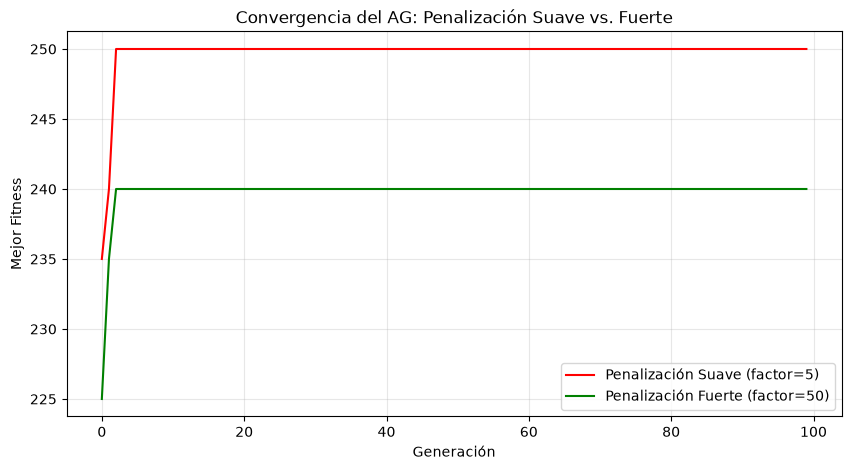

In [17]:
# ---------- Ejercicio 4: Gráfica de convergencia (Suave vs. Fuerte) ----------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(hist_suave, label=f'Penalización Suave (factor={PENALTY_SUAVE})', color='red')
plt.plot(hist_fuerte, label=f'Penalización Fuerte (factor={PENALTY_FUERTE})', color='green')
plt.xlabel('Generación')
plt.ylabel('Mejor Fitness')
plt.title('Convergencia del AG: Penalización Suave vs. Fuerte')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()